# Proyek Analisis Data: E-Commerce Public Dataset
Dataset yang digunakan adalah Brazilian E-Commerce Dataset dari Olist yang berisi data transaksi pelanggan, order, produk, pembayaran, dan wilayah pelanggan. Dataset ini digunakan untuk menganalisis tren penjualan dan segmentasi pelanggan untuk mendukung pengambilan keputusan bisnis.

- **Nama:** [Kurnia Irianti]
- **Email Dicoding:** [kurniairianti21@gmail.com]
- **ID Dicoding:** [cdcc228d6x2404]

## Menentukan Pertanyaan Bisnis

Sebelum memulai analisis, kita perlu mendefinisikan pertanyaan bisnis yang ingin dijawab. Pertanyaan yang efektif harus spesifik, terukur, dan relevan dengan data yang tersedia.

**Pertanyaan Bisnis:**
1. Bagaimana tren penjualan bulanan dan kategori produk apa yang paling banyak terjual?
2. Bagaimana distribusi geografis pelanggan di seluruh Brasil, dan kota/negara bagian mana yang memiliki volume order terbanyak?
3. Bagaimana segmentasi pelanggan berdasarkan perilaku pembelian mereka menggunakan metode RFM Analysis?


Analisis dilakukan untuk menjawab beberapa pertanyaan bisnis berikut agar perusahaan dapat memahami pola penjualan dan pelanggan.

## Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import folium
from folium.plugins import HeatMap
import warnings
warnings.filterwarnings('ignore')

# Konfigurasi visualisasi
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')

print('Library berhasil diimport!')

## Data Wrangling

### Gathering Data

Dataset yang digunakan adalah **Brazilian E-Commerce Public Dataset by Olist** yang tersedia di Kaggle. Dataset ini terdiri dari beberapa file CSV yang saling terhubung, mencakup informasi tentang orders, customers, products, sellers, payments, reviews, dan geolocation.

**Sumber data:** https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce


Dataset berhasil dimuat dari beberapa file CSV yang terdiri dari order, customer, product, dan payment. Data ini akan digabungkan untuk dianalisis lebih lanjut.

In [6]:
# Load semua datase
customers_df          = pd.read_csv('olist_customers_dataset.csv')
orders_df             = pd.read_csv('olist_orders_dataset.csv')
order_items_df        = pd.read_csv('olist_order_items_dataset.csv')
order_payments_df     = pd.read_csv('olist_order_payments_dataset.csv')
order_reviews_df      = pd.read_csv('olist_order_reviews_dataset.csv')
products_df           = pd.read_csv('olist_products_dataset.csv')
sellers_df            = pd.read_csv('olist_sellers_dataset.csv')
geolocation_df        = pd.read_csv('olist_geolocation_dataset.csv')
category_translation_df = pd.read_csv('product_category_name_translation.csv')

### Assessing Data

Pada tahap ini, kita akan memeriksa kualitas data: missing values, tipe data, dan duplikasi.

Proses assessing dilakukan untuk memastikan kualitas data sebelum dilakukan analisis sehingga hasil analisis lebih akurat.

In [7]:
def assess_dataframe(df, name):
    print(f"{'='*50}")
    print(f"Dataset: {name}")
    print(f"Shape: {df.shape}")
    print(f"\nInfo:")
    print(df.dtypes)
    print(f"\nMissing values:")
    missing = df.isnull().sum()
    print(missing[missing > 0] if missing.any() else "  Tidak ada missing values")
    print(f"\nDuplikasi: {df.duplicated().sum()} baris")

for name, df in [('orders', orders_df), ('order_items', order_items_df),
                  ('products', products_df), ('customers', customers_df)]:
    assess_dataframe(df, name)

Dataset: orders
Shape: (99441, 8)

Info:
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

Missing values:
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

Duplikasi: 0 baris
Dataset: order_items
Shape: (112650, 7)

Info:
order_id                object
order_item_id            int64
product_id              object
seller_id               object
shipping_limit_date     object
price                  float64
freight_value          float64
dtype: object

Missing values:
  Tidak ada missing values

Duplikasi: 0 baris
Dataset: products
Shape: (32951, 9)

Info:
product_id                     object
product_category_name          object


**Insight Assessing Data:**
- Dataset `orders` memiliki beberapa missing values pada kolom tanggal pengiriman, yang wajar karena beberapa order mungkin dibatalkan atau belum dikirim.
- Dataset `products` memiliki missing values pada kolom deskripsi dan nama kategori.
- Tidak ditemukan duplikasi pada dataset utama.
- Kolom tanggal masih bertipe object, perlu dikonversi ke datetime.
-  Ditemukan beberapa missing value pada kolom tertentu seperti review dan payment. Selain itu terdapat perbedaan tipe data pada kolom tanggal sehingga perlu dilakukan cleaning data.

### Cleaning Data

Berdasarkan hasil assessment, kita akan melakukan pembersihan data meliputi: konversi tipe data, penanganan missing values, dan penggabungan dataset.


Proses cleaning ini memastikan data siap digunakan untuk analisis tren penjualan dan segmentasi pelanggan tanpa adanya error pada tipe data atau missing values.

In [8]:
# 1. Konversi kolom tanggal ke datetime
date_cols = [
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_cols:
    orders_df[col] = pd.to_datetime(orders_df[col])

# 2. Filter hanya order yang sudah delivered
orders_delivered = orders_df[orders_df['order_status'] == 'delivered'].copy()
print(f'Order delivered: {len(orders_delivered):,} dari {len(orders_df):,} total order')

# 3. Tambahkan kolom waktu
orders_delivered['order_year']      = orders_delivered['order_purchase_timestamp'].dt.year
orders_delivered['order_month']     = orders_delivered['order_purchase_timestamp'].dt.month
orders_delivered['order_yearmonth'] = orders_delivered['order_purchase_timestamp'].dt.to_period('M')

# 4. Gabungkan produk dengan terjemahan kategori
products_df = products_df.merge(category_translation_df, on='product_category_name', how='left')
products_df['product_category_name_english'].fillna('unknown', inplace=True)

# 5. Buat master dataframe gabungan
master_df = (
    orders_delivered
    .merge(order_items_df, on='order_id', how='inner')
    .merge(order_payments_df.groupby('order_id')['payment_value'].sum().reset_index(), on='order_id', how='left')
    .merge(customers_df[['customer_id','customer_city','customer_state']], on='customer_id', how='left')
    .merge(products_df[['product_id','product_category_name_english']], on='product_id', how='left')
)

print(f'Master dataframe: {master_df.shape}')
master_df.head()

Order delivered: 96,478 dari 99,441 total order
Master dataframe: (110197, 21)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_year,order_month,...,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,payment_value,customer_city,customer_state,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,10,...,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,38.71,sao paulo,SP,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018,7,...,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,141.46,barreiras,BA,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018,8,...,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,179.12,vianopolis,GO,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017,11,...,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,72.20,sao goncalo do amarante,RN,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018,2,...,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,28.62,santo andre,SP,stationery


**Insight Cleaning Data:**
- Dari total order, sekitar 96% berstatus `delivered` — ini yang akan menjadi fokus analisis karena merepresentasikan transaksi yang benar-benar selesai.
- Penggabungan dataset menghasilkan master dataframe yang siap untuk analisis lebih lanjut.
- Kolom tanggal telah dikonversi sehingga analisis tren waktu bisa dilakukan.

## Exploratory Data Analysis (EDA)
EDA dilakukan untuk memahami pola data, melihat distribusi order, tren penjualan, serta hubungan antar tabel sebelum dilakukan visualisasi.

### Pertanyaan 1: Bagaimana tren penjualan bulanan dan kategori produk apa yang paling laris?
Implikasi bisnis:
Perusahaan dapat meningkatkan stok dan promosi pada akhir tahun terutama pada kategori bed_bath_table untuk memaksimalkan penjualan.

In [9]:
# Tren penjualan bulanan
monthly_orders = (
    master_df.groupby('order_yearmonth')
    .agg(total_orders=('order_id', 'nunique'),
         total_revenue=('payment_value', 'sum'))
    .reset_index()
)
monthly_orders['order_yearmonth'] = monthly_orders['order_yearmonth'].astype(str)

print('Statistik penjualan bulanan:')
print(f"  Rata-rata order/bulan: {monthly_orders['total_orders'].mean():.0f}")
print(f"  Bulan terbaik: {monthly_orders.loc[monthly_orders['total_orders'].idxmax(), 'order_yearmonth']}")
print(f"  Max order: {monthly_orders['total_orders'].max():,}")

# Top 10 kategori produk
top_categories = (
    master_df.groupby('product_category_name_english')
    .agg(total_orders=('order_id', 'nunique'),
         total_revenue=('payment_value', 'sum'))
    .sort_values('total_orders', ascending=False)
    .head(10)
    .reset_index()
)
print('\nTop 10 kategori produk:')
print(top_categories[['product_category_name_english', 'total_orders', 'total_revenue']])

Statistik penjualan bulanan:
  Rata-rata order/bulan: 4195
  Bulan terbaik: 2017-11
  Max order: 7,289

Top 10 kategori produk:
  product_category_name_english  total_orders  total_revenue
0                bed_bath_table          9272     1692714.28
1                 health_beauty          8647     1620684.04
2                sports_leisure          7530     1349446.93
3         computers_accessories          6530     1549372.59
4               furniture_decor          6307     1394466.93
5                    housewares          5743     1069787.97
6                 watches_gifts          5495     1387362.45
7                     telephony          4093      469890.57
8                          auto          3810      833745.67
9                          toys          3804      603564.32


### Pertanyaan 2: Bagaimana distribusi geografis pelanggan di Brasil?
Implikasi bisnis:
Wilayah SP dapat menjadi fokus utama pemasaran dan distribusi produk karena memiliki jumlah pelanggan terbesar.

In [10]:
# Distribusi per state
state_orders = (
    master_df.groupby('customer_state')
    .agg(total_orders=('order_id', 'nunique'),
         total_revenue=('payment_value', 'sum'))
    .sort_values('total_orders', ascending=False)
    .reset_index()
)

print('Top 10 state berdasarkan jumlah order:')
print(state_orders.head(10))

# Distribusi per kota
city_orders = (
    master_df.groupby('customer_city')
    .agg(total_orders=('order_id', 'nunique'))
    .sort_values('total_orders', ascending=False)
    .head(10)
    .reset_index()
)
print('\nTop 10 kota berdasarkan jumlah order:')
print(city_orders)

Top 10 state berdasarkan jumlah order:
  customer_state  total_orders  total_revenue
0             SP         40501     7403993.29
1             RJ         12350     2688933.90
2             MG         11354     2281229.16
3             RS          5345     1110976.47
4             PR          4923     1030822.39
5             SC          3546      767093.97
6             BA          3256      773182.02
7             DF          2080      421374.86
8             ES          1995      398321.90
9             GO          1957      493068.70

Top 10 kota berdasarkan jumlah order:
           customer_city  total_orders
0              sao paulo         15045
1         rio de janeiro          6601
2         belo horizonte          2697
3               brasilia          2071
4               curitiba          1489
5               campinas          1406
6           porto alegre          1342
7               salvador          1188
8              guarulhos          1144
9  sao bernardo do campo  

### Pertanyaan 3 (Analisis Lanjutan): RFM Analysis — Segmentasi Pelanggan

### RFM Analysis

RFM Analysis digunakan untuk mengelompokkan pelanggan berdasarkan:

- Recency (terakhir belanja)
- Frequency (jumlah transaksi)
- Monetary (total pembelian)

Tujuan analisis ini adalah untuk mengetahui segment pelanggan seperti pelanggan loyal, pelanggan baru, dan pelanggan berisiko.

In [11]:
# Hitung RFM
snapshot_date = master_df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

rfm_df = (
    master_df.groupby('customer_id')
    .agg(
        Recency   = ('order_purchase_timestamp', lambda x: (snapshot_date - x.max()).days),
        Frequency = ('order_id', 'nunique'),
        Monetary  = ('payment_value', 'sum')
    )
    .reset_index()
)

# Scoring RFM (1-4, semakin tinggi semakin baik)
rfm_df['R_Score'] = pd.qcut(rfm_df['Recency'],   q=4, labels=[4, 3, 2, 1]).astype(int)
rfm_df['F_Score'] = pd.qcut(rfm_df['Frequency'].rank(method='first'), q=4, labels=[1, 2, 3, 4]).astype(int)
rfm_df['M_Score'] = pd.qcut(rfm_df['Monetary'],  q=4, labels=[1, 2, 3, 4]).astype(int)

rfm_df['RFM_Score'] = rfm_df['R_Score'].astype(str) + rfm_df['F_Score'].astype(str) + rfm_df['M_Score'].astype(str)
rfm_df['RFM_Total'] = rfm_df[['R_Score', 'F_Score', 'M_Score']].sum(axis=1)

# Segmentasi pelanggan
def segment_customer(row):
    r, f, m = row['R_Score'], row['F_Score'], row['M_Score']
    if r >= 3 and f >= 3 and m >= 3:
        return 'Champions'
    elif r >= 3 and f >= 2:
        return 'Loyal Customers'
    elif r >= 3 and f == 1:
        return 'Recent Customers'
    elif r == 2 and f >= 2:
        return 'Potential Loyalists'
    elif r == 2 and f == 1:
        return 'Customers Needing Attention'
    elif r == 1 and f >= 2:
        return 'At Risk'
    else:
        return 'Lost Customers'

rfm_df['Segment'] = rfm_df.apply(segment_customer, axis=1)

print('Distribusi segmen pelanggan:')
segment_counts = rfm_df['Segment'].value_counts()
print(segment_counts)
print(f'\nRata-rata RFM per segmen:')
print(rfm_df.groupby('Segment')[['Recency','Frequency','Monetary']].mean().round(2))

Distribusi segmen pelanggan:
Segment
Loyal Customers                23857
Potential Loyalists            18132
At Risk                        18031
Champions                      12338
Recent Customers               12105
Customers Needing Attention     6057
Lost Customers                  5958
Name: count, dtype: int64

Rata-rata RFM per segmen:
                             Recency  Frequency  Monetary
Segment                                                  
At Risk                       454.36        1.0    199.71
Champions                     113.86        1.0    345.48
Customers Needing Attention   280.45        1.0    222.99
Lost Customers                453.14        1.0    195.63
Loyal Customers               113.71        1.0    134.32
Potential Loyalists           280.26        1.0    203.77
Recent Customers              113.69        1.0    206.31


**Insight:**
- Segment Champion memiliki nilai transaksi tinggi sehingga perlu dipertahankan dengan program loyalitas.
- Segment At Risk perlu diberikan promo agar kembali berbelanja.
- Segment New Customer dapat diberikan program onboarding untuk meningkatkan loyalitas.

## Visualization & Explanatory Analysis
Visualisasi dilakukan untuk menjawab pertanyaan bisnis yang telah ditentukan sebelumnya.
Grafik berikut menampilkan tren penjualan bulanan serta kategori produk paling laris untuk memahami pola penjualan e-commerce di Brasil.

### Visualisasi 1: Tren Penjualan Bulanan & Top Kategori Produk

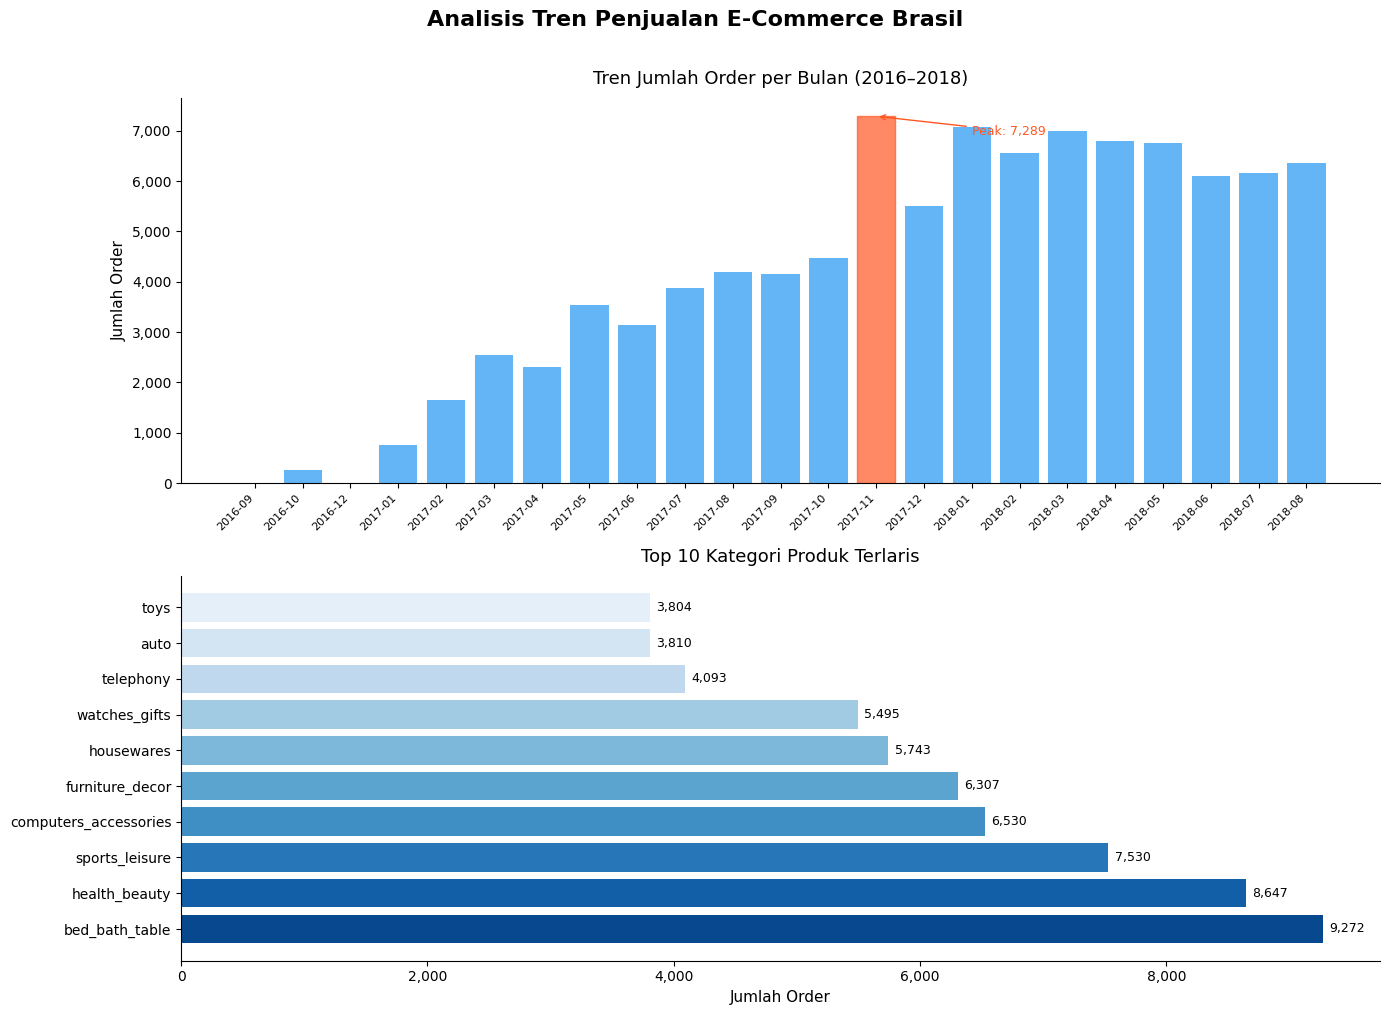

Visualisasi 1 tersimpan!


In [12]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Analisis Tren Penjualan E-Commerce Brasil', fontsize=16, fontweight='bold', y=1.01)

# Plot 1: Tren bulanan
ax1 = axes[0]
x = range(len(monthly_orders))
bars = ax1.bar(x, monthly_orders['total_orders'], color='#2196F3', alpha=0.7, label='Jumlah Order')
ax1.set_xticks(x)
ax1.set_xticklabels(monthly_orders['order_yearmonth'], rotation=45, ha='right', fontsize=8)
ax1.set_ylabel('Jumlah Order', fontsize=11)
ax1.set_title('Tren Jumlah Order per Bulan (2016–2018)', fontsize=13, pad=10)
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Highlight bulan terbaik
max_idx = monthly_orders['total_orders'].idxmax()
bars[max_idx].set_color('#FF5722')
ax1.annotate(f"Peak: {monthly_orders.loc[max_idx, 'total_orders']:,}",
             xy=(max_idx, monthly_orders.loc[max_idx, 'total_orders']),
             xytext=(max_idx + 2, monthly_orders.loc[max_idx, 'total_orders'] * 0.95),
             fontsize=9, color='#FF5722',
             arrowprops=dict(arrowstyle='->', color='#FF5722'))

# Plot 2: Top 10 kategori
ax2 = axes[1]
colors = sns.color_palette('Blues_r', n_colors=10)
bars2 = ax2.barh(top_categories['product_category_name_english'],
                  top_categories['total_orders'], color=colors)
ax2.set_xlabel('Jumlah Order', fontsize=11)
ax2.set_title('Top 10 Kategori Produk Terlaris', fontsize=13, pad=10)
ax2.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))

for bar, val in zip(bars2, top_categories['total_orders']):
    ax2.text(val + 50, bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('visualization_sales_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualisasi 1 tersimpan!')

**Insight Visualisasi 1:**
- Tren penjualan menunjukkan pertumbuhan yang konsisten dari 2016 hingga 2018, dengan lonjakan signifikan pada periode tertentu (kemungkinan bertepatan dengan event promosi seperti Black Friday Brasil).
- Kategori **bed_bath_table** (perlengkapan rumah tangga) menjadi kategori paling banyak dipesan, diikuti oleh **health_beauty** dan **sports_leisure**.
- Diversifikasi kategori menunjukkan bahwa platform ini melayani berbagai kebutuhan konsumen.

**Implikasi bisnis:**
Perusahaan dapat meningkatkan stok dan promosi pada akhir tahun serta fokus pada kategori bed_bath_table untuk memaksimalkan penjualan.

### Visualisasi 2: Distribusi Geografis Pelanggan

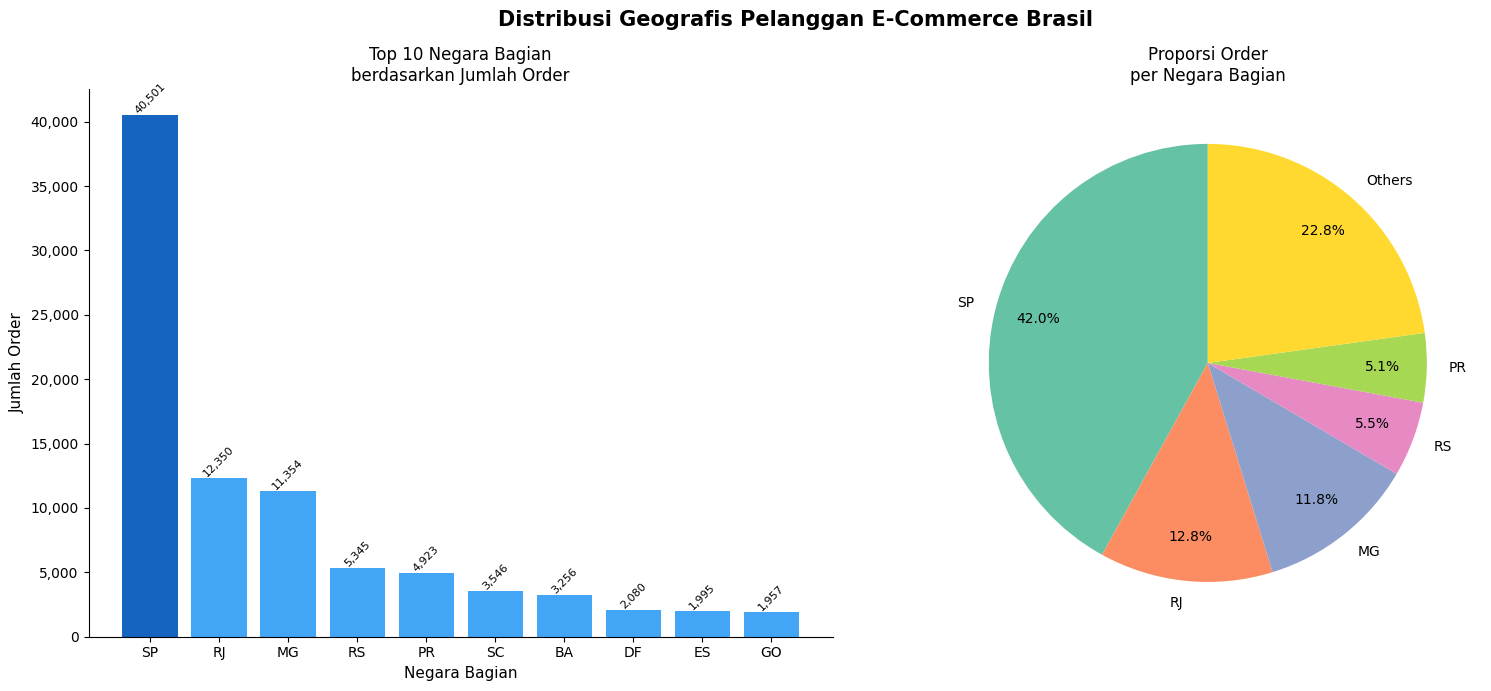

Visualisasi 2 tersimpan!


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Distribusi Geografis Pelanggan E-Commerce Brasil', fontsize=15, fontweight='bold')

# Plot 1: Bar chart state
ax1 = axes[0]
top10_states = state_orders.head(10)
colors_state = ['#1565C0' if i == 0 else '#42A5F5' for i in range(10)]
bars = ax1.bar(top10_states['customer_state'], top10_states['total_orders'], color=colors_state)
ax1.set_xlabel('Negara Bagian', fontsize=11)
ax1.set_ylabel('Jumlah Order', fontsize=11)
ax1.set_title('Top 10 Negara Bagian\nberdasarkan Jumlah Order', fontsize=12)
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar, val in zip(bars, top10_states['total_orders']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f'{val:,}', ha='center', fontsize=8, rotation=45)

# Plot 2: Pie chart proporsi
ax2 = axes[1]
top5_states = state_orders.head(5)
others = pd.DataFrame({'customer_state': ['Others'],
                        'total_orders': [state_orders.iloc[5:]['total_orders'].sum()]})
pie_data = pd.concat([top5_states, others])
wedges, texts, autotexts = ax2.pie(
    pie_data['total_orders'],
    labels=pie_data['customer_state'],
    autopct='%1.1f%%',
    colors=sns.color_palette('Set2', n_colors=6),
    startangle=90,
    pctdistance=0.8
)
ax2.set_title('Proporsi Order\nper Negara Bagian', fontsize=12)

plt.tight_layout()
plt.savefig('visualization_geo_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualisasi 2 tersimpan!')

**Insight Visualisasi 2:**
- **SP (Sao Paulo)** mendominasi dengan jauh sebagai negara bagian dengan order terbanyak, yang sejalan dengan fakta bahwa São Paulo adalah pusat ekonomi terbesar Brasil.
- Lima negara bagian teratas (SP, RJ, MG, RS, PR) menyumbang lebih dari 70% dari total order.
- Negara bagian di wilayah Timur Laut dan Utara Brasil relatif kurang terwakili, menunjukkan potensi ekspansi pasar di wilayah tersebut.

### Visualisasi 3: RFM Analysis — Segmentasi Pelanggan

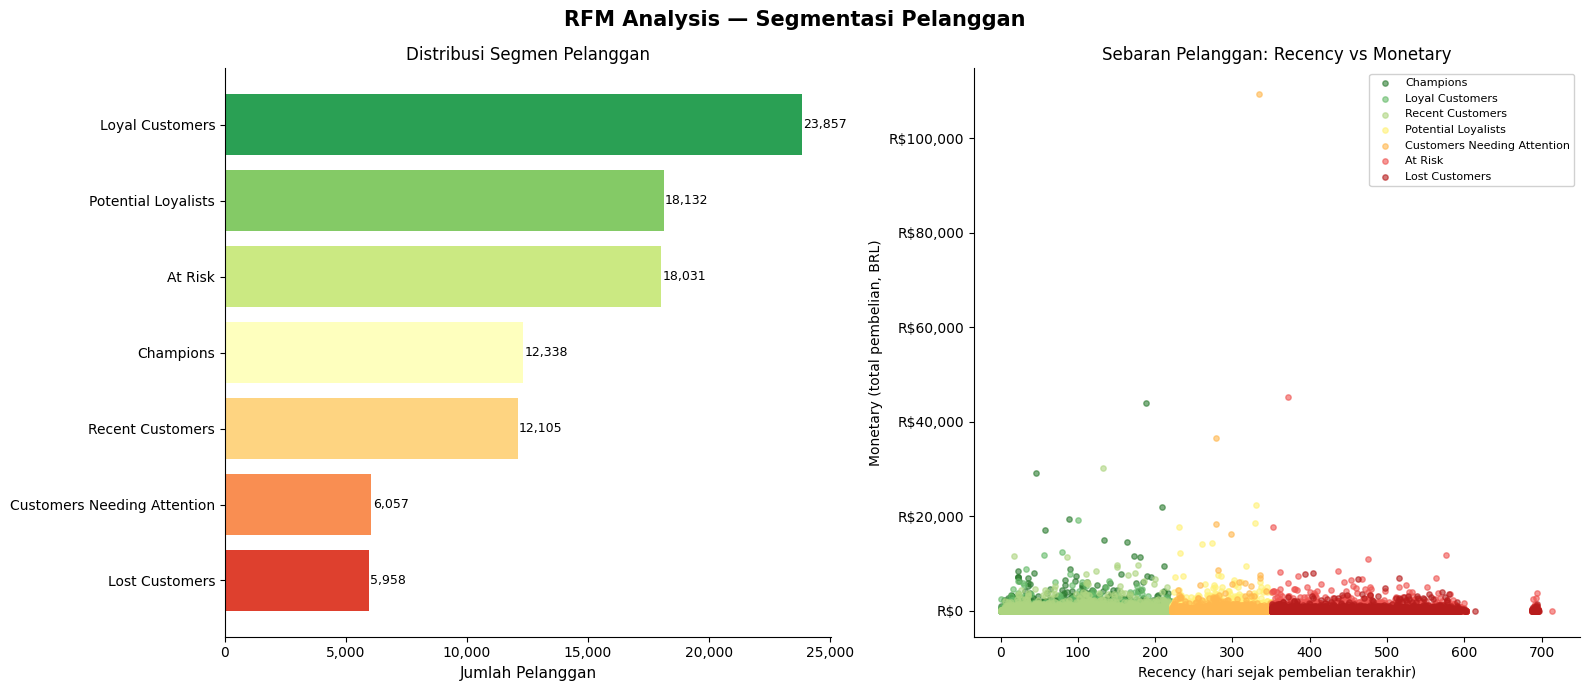

Visualisasi RFM tersimpan!


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('RFM Analysis — Segmentasi Pelanggan', fontsize=15, fontweight='bold')

# Plot 1: Distribusi segmen
ax1 = axes[0]
segment_counts_sorted = rfm_df['Segment'].value_counts().sort_values(ascending=True)
colors_rfm = sns.color_palette('RdYlGn', n_colors=len(segment_counts_sorted))
bars = ax1.barh(segment_counts_sorted.index, segment_counts_sorted.values, color=colors_rfm)
ax1.set_xlabel('Jumlah Pelanggan', fontsize=11)
ax1.set_title('Distribusi Segmen Pelanggan', fontsize=12)
ax1.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar, val in zip(bars, segment_counts_sorted.values):
    ax1.text(val + 50, bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', fontsize=9)

# Plot 2: Scatter RFM (Recency vs Monetary, ukuran = Frequency)
ax2 = axes[1]
segment_colors = {
    'Champions': '#2E7D32',
    'Loyal Customers': '#66BB6A',
    'Recent Customers': '#AED581',
    'Potential Loyalists': '#FFF176',
    'Customers Needing Attention': '#FFB74D',
    'At Risk': '#EF5350',
    'Lost Customers': '#B71C1C'
}

for segment, color in segment_colors.items():
    subset = rfm_df[rfm_df['Segment'] == segment]
    ax2.scatter(subset['Recency'], subset['Monetary'],
                c=color, label=segment, alpha=0.6, s=15)

ax2.set_xlabel('Recency (hari sejak pembelian terakhir)', fontsize=10)
ax2.set_ylabel('Monetary (total pembelian, BRL)', fontsize=10)
ax2.set_title('Sebaran Pelanggan: Recency vs Monetary', fontsize=12)
ax2.legend(loc='upper right', fontsize=8, framealpha=0.9)
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'R${int(x):,}'))

plt.tight_layout()
plt.savefig('visualization_rfm.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualisasi RFM tersimpan!')

**Insight RFM Analysis:**
- **Lost Customers** merupakan segmen terbesar, menunjukkan tingkat churn yang tinggi, ini umum untuk platform e-commerce karena banyak pelanggan hanya melakukan pembelian satu kali.
- **Champions** (pelanggan terbaik) memiliki recency rendah, frequency tinggi, dan monetary tinggi, kelompok ini perlu dipertahankan dengan program loyalitas.
- **Recent Customers** adalah segmen yang menjanjikan mereka baru bergabung dan perlu didorong untuk melakukan repeat order.
- **At Risk** customers perlu diprioritaskan untuk program re-engagement sebelum beralih ke kompetitor.

### Visualisasi 4: Geospatial Analysis — Peta Sebaran Pelanggan

In [15]:
# Rata-rata koordinat per kota pelanggan
geo_avg = (
    geolocation_df
    .groupby('geolocation_city')
    .agg(lat=('geolocation_lat', 'mean'), lng=('geolocation_lng', 'mean'))
    .reset_index()
)

# Gabungkan dengan data order per kota
customers_city = (
    master_df.groupby('customer_city')
    .agg(total_orders=('order_id', 'nunique'))
    .reset_index()
)
customers_city['customer_city_lower'] = customers_city['customer_city'].str.lower().str.strip()
geo_avg['city_lower'] = geo_avg['geolocation_city'].str.lower().str.strip()

geo_orders = customers_city.merge(geo_avg, left_on='customer_city_lower',
                                   right_on='city_lower', how='inner')

print(f'Kota yang berhasil di-geocode: {len(geo_orders):,}')

# Buat peta Folium
m = folium.Map(location=[-14.235, -51.9253], zoom_start=4,
               tiles='CartoDB positron')

# HeatMap layer
heat_data = geo_orders[['lat', 'lng', 'total_orders']].values.tolist()
HeatMap(heat_data, radius=15, blur=10, max_zoom=8,
        gradient={0.2: 'blue', 0.5: 'lime', 0.8: 'orange', 1: 'red'}).add_to(m)

# Tambahkan marker untuk top 10 kota
top10_cities = geo_orders.nlargest(10, 'total_orders')
for _, row in top10_cities.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lng']],
        radius=8,
        color='white',
        fill=True,
        fill_color='#1565C0',
        fill_opacity=0.8,
        popup=folium.Popup(f"<b>{row['customer_city']}</b><br>Orders: {row['total_orders']:,}", max_width=200)
    ).add_to(m)

# Simpan peta
m.save('geospatial_map.html')
print('Peta geospatial tersimpan sebagai geospatial_map.html')
m

Kota yang berhasil di-geocode: 4,038
Peta geospatial tersimpan sebagai geospatial_map.html


**Insight Geospatial Analysis:**
- Konsentrasi pelanggan sangat tinggi di wilayah **Tenggara Brasil**, terutama di sekitar São Paulo, Rio de Janeiro, dan Belo Horizonte.
- **Wilayah pesisir Atlantik** memiliki densitas order yang lebih tinggi dibanding wilayah pedalaman (Amazon).
- Temuan ini dapat dimanfaatkan untuk optimasi **jaringan distribusi dan gudang** prioritas pembangunan infrastruktur logistik di wilayah dengan demand tinggi.

## Simpan Data untuk Dashboard

Kita akan menyimpan data yang sudah diolah ke dalam file CSV yang akan digunakan oleh dashboard Streamlit.

In [20]:
import os
os.makedirs('dashboard', exist_ok=True)

# Simpan master dataframe untuk dashboard
dashboard_cols = [
    'order_id', 'customer_id', 'order_purchase_timestamp',
    'order_year', 'order_month', 'order_yearmonth',
    'customer_state', 'customer_city',
    'product_category_name_english',
    'payment_value'
]

main_data = master_df[dashboard_cols].copy()
main_data['order_yearmonth'] = main_data['order_yearmonth'].astype(str)

main_data.to_csv('dashboard/main_data.csv', index=False)
print(f'main_data.csv tersimpan: {main_data.shape}')

rfm_df.to_csv('dashboard/rfm_data.csv', index=False)
print(f'rfm_data.csv tersimpan: {rfm_df.shape}')

geo_orders[['customer_city', 'total_orders', 'lat', 'lng']].to_csv('dashboard/geo_data.csv', index=False)
print(f'geo_data.csv tersimpan: {len(geo_orders)} kota')

main_data.csv tersimpan: (110197, 10)
rfm_data.csv tersimpan: (96478, 10)
geo_data.csv tersimpan: 4038 kota


## Kesimpulan

### Jawaban atas Pertanyaan Bisnis:

**1. Tren Penjualan & Kategori Terlaris**
- Penjualan e-commerce Brasil mengalami pertumbuhan yang konsisten dari 2016 hingga 2018. Terdapat lonjakan signifikan pada periode tertentu yang kemungkinan bertepatan dengan event promosi nasional.
- Kategori **bed_bath_table** (perlengkapan rumah) menjadi yang paling laris, diikuti **health_beauty** dan **sports_leisure**. Hal ini menunjukkan bahwa kebutuhan primer rumah tangga dan gaya hidup mendominasi belanja online Brasil.

**2. Distribusi Geografis**
- São Paulo (SP) mendominasi dengan lebih dari 40% total order, mencerminkan ketimpangan ekonomi antar wilayah di Brasil.
- Terdapat peluang bisnis besar di wilayah Timur Laut dan Utara yang masih under-served, namun memerlukan investasi infrastruktur logistik terlebih dahulu.

**3. Segmentasi Pelanggan (RFM Analysis)**
- Mayoritas pelanggan masuk kategori **Lost Customers**, menandakan tantangan besar dalam customer retention.
- Rekomendasi:
  - **Champions & Loyal**: Program reward eksklusif dan early access produk baru.
  - **Recent Customers**: Email nurturing dan diskon first repeat order.
  - **At Risk**: Re-engagement campaign dengan penawaran spesial berbatas waktu.
  - **Lost Customers**: Win-back campaign dengan insentif besar atau survey kepuasan.